In [ ]:
import os, cv2, torch, random
import numpy as np
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler  # added this for handling class imbalance
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# list of all shot classes in dataset
CLASSES = ['cover','defense','flick','hook','late_cut',
           'lofted','pull','square_cut','straight','sweep']

NUM_CLASSES = 10  # total number of classes

FRAME_SIZE  = (224, 224)  # resizing frames to fixed size for model
NUM_FRAMES  = 16  # keeping 16 frames from each video (earlier thought of 24 but using 16 here)

BATCH_SIZE  = 8   # batch size (kept a bit small to avoid memory issues)

NUM_EPOCHS  = 15  # total training epochs
LR          = 1e-3  # learning rate

DROPOUT     = 0.65  # higher dropout to reduce overfitting

PATIENCE    = 4    # early stopping if no improvement for 4 epochs

HIDDEN_SIZE = 256  # size of hidden layer in RNN

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if available

# dataset path (kaggle input)
DATA_DIR    = '/kaggle/input/datasets/peeyushsahu123/cricketdataset/CricShot10 dataset'

# folders to save checkpoints and results
CKPT_DIR    = '/kaggle/working/checkpoints'
RES_DIR     = '/kaggle/working/results'

# create folders if not already present
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RES_DIR,  exist_ok=True)

_shared_splits = {}  # will store train/val splits to reuse later

# just printing some basic info to check everything is fine
print(f"Device : {DEVICE}")
print(f"DATA_DIR exists: {os.path.exists(DATA_DIR)}")

Device : cuda
DATA_DIR exists: True


In [ ]:
def extract_frames(path):
    cap = cv2.VideoCapture(path)  # open video file
    frames = []
    while True:
        ret, frame = cap.read()  # read frame one by one
        if not ret: break  # stop when video ends
        # resize and convert to RGB (opencv reads in BGR)
        frames.append(cv2.cvtColor(
            cv2.resize(frame, FRAME_SIZE), cv2.COLOR_BGR2RGB))
    cap.release()  # release video
    return frames  # return all frames


def uniform_sampling(frames, n):
    # simple sampling: pick frames evenly from whole video
    if not frames:
        # if no frames, just return blank frames
        return [np.zeros((*FRAME_SIZE, 3), dtype=np.uint8)] * n
    if len(frames) <= n:
        # if frames are less, just repeat last frame
        return frames + [frames[-1]] * (n - len(frames))
    # pick evenly spaced indices
    return [frames[i] for i in np.linspace(0, len(frames)-1, n, dtype=int)]


def compute_motion_scores(frames):
    # calculate motion between consecutive frames
    scores = [0.0]  # first frame has no previous frame
    for i in range(1, len(frames)):
        # convert to grayscale for easier difference calculation
        g1 = cv2.cvtColor(frames[i-1], cv2.COLOR_RGB2GRAY).astype(np.float32)
        g2 = cv2.cvtColor(frames[i],   cv2.COLOR_RGB2GRAY).astype(np.float32)
        # take absolute difference and average
        scores.append(float(np.mean(np.abs(g2 - g1))))
    return np.array(scores)


def motion_sampling(frames, n):  # improved version
    """
    tries to focus on important motion parts but also keeps some context
    """
    if len(frames) <= n:
        return frames + [frames[-1]] * (n - len(frames))
    
    scores = compute_motion_scores(frames)  # get motion scores
    
    # take top motion frames
    top_n = min(n, len(frames))
    top_indices = set(np.argsort(scores)[-top_n:])
    
    # also include nearby frames (context)
    context_indices = set()
    for idx in top_indices:
        for offset in [-3, -2, -1, 1, 2, 3]:
            neighbor = idx + offset
            if 0 <= neighbor < len(frames):
                context_indices.add(neighbor)
    
    # combine both
    all_indices = top_indices | context_indices
    
    # if still less frames, add some uniform ones
    if len(all_indices) < n:
        remaining = n - len(all_indices)
        uniform = set(np.linspace(0, len(frames)-1, remaining, dtype=int))
        all_indices |= uniform
    
    # sort and take first n
    result_indices = sorted(all_indices)[:n]
    return [frames[i] for i in result_indices]


def hybrid_sampling(frames, n):  # improved version
    # mix of motion + uniform + random (balanced approach)
    if len(frames) <= n:
        return frames + [frames[-1]] * (n - len(frames))
    
    motion_n = int(n * 0.4)   # 40% motion
    uniform_n = int(n * 0.4)  # 40% uniform
    random_n = n - motion_n - uniform_n  # rest random
    
    scores = compute_motion_scores(frames)
    
    # motion-based indices
    motion_indices = set(np.argsort(scores)[-motion_n:])
    
    # add nearby frames for better context
    context_indices = set()
    for idx in motion_indices:
        for offset in [-2, -1, 1, 2]:
            neighbor = idx + offset
            if 0 <= neighbor < len(frames):
                context_indices.add(neighbor)
    motion_indices |= context_indices
    
    # uniform sampling
    uniform_indices = set(np.linspace(0, len(frames)-1, uniform_n, dtype=int))
    
    # random sampling from remaining frames
    remaining_indices = [i for i in range(len(frames)) 
                         if i not in motion_indices and i not in uniform_indices]
    random_indices = set()
    if remaining_indices and random_n > 0:
        random_indices = set(np.random.choice(
            remaining_indices, min(random_n, len(remaining_indices)), replace=False))
    
    # combine all indices
    all_indices = sorted(motion_indices | uniform_indices | random_indices)
    
    # if still less, just repeat last index
    while len(all_indices) < n:
        all_indices.append(all_indices[-1])
    
    return [frames[i] for i in all_indices[:n]]


def sample_frames(frames, n, strategy):
    # choose sampling method
    if strategy == 'uniform': return uniform_sampling(frames, n)
    if strategy == 'motion':  return motion_sampling(frames, n)
    if strategy == 'hybrid':  return hybrid_sampling(frames, n)
    raise ValueError(strategy)  # wrong strategy name


print("Sampling ready ✓")  # just to check everything loaded properly

Sampling ready ✓


In [ ]:
class CricketDataset(Dataset):
    def __init__(self, paths, labels, strategy, augment=False):
        self.paths    = paths
        self.labels   = labels
        self.strategy = strategy
        
        # apply temporal augmentation only for motion/hybrid
        self.temporal_augment = augment and strategy in ['motion', 'hybrid']
        
        # spatial augmentation (simple transformations)
        aug = ([
            transforms.RandomHorizontalFlip(),  # flip image randomly
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # change colors slightly
            transforms.RandomRotation(5),  # small rotation
        ] if augment else [])
        
        # final transform pipeline
        self.tf = transforms.Compose([
            transforms.ToPILImage(),
            *aug,
            transforms.Resize(FRAME_SIZE),  # resize to fixed size
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),  # normalize like imagenet
        ])
    
    def __len__(self): 
        return len(self.paths)  # total number of samples
    
    def __getitem__(self, idx):
        frames = extract_frames(self.paths[idx])  # get frames from video
        if not frames:
            # if video failed to load, use blank frame
            frames = [np.zeros((*FRAME_SIZE, 3), dtype=np.uint8)]
        
        frames = sample_frames(frames, NUM_FRAMES, self.strategy)  # sample frames
        
        # temporal augmentation (drop some frames randomly)
        if self.temporal_augment and np.random.random() > 0.5:
            drop_count = random.randint(1, min(3, len(frames)-1))
            drop_indices = sorted(random.sample(range(len(frames)), drop_count))
            frames = [f for i, f in enumerate(frames) if i not in drop_indices]
            
            # add frames back to maintain fixed length
            while len(frames) < NUM_FRAMES:
                frames.append(frames[-1] if frames else np.zeros((*FRAME_SIZE, 3), dtype=np.uint8))
        
        # small shift in frames (like moving forward/backward in time)
        if self.temporal_augment and np.random.random() > 0.7:
            shift = random.randint(-2, 2)
            if shift > 0:
                frames = frames[shift:] + [frames[-1]] * min(shift, len(frames))
            elif shift < 0:
                frames = [frames[0]] * abs(shift) + frames[:shift]
        
        # convert all frames to tensor and return with label
        return (torch.stack([self.tf(f) for f in frames]),
                torch.tensor(self.labels[idx], dtype=torch.long))


def get_loaders(strategy):
    # this function prepares train, val and test loaders
    global _shared_splits
    
    if not _shared_splits:
        paths, labels = [], []
        
        # read all video paths class-wise
        for i, cls in enumerate(CLASSES):
            d = os.path.join(DATA_DIR, cls)
            if not os.path.isdir(d): continue
            
            vids = [f for f in os.listdir(d)
                    if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
            
            for f in vids:
                paths.append(os.path.join(d, f))
                labels.append(i)
            
            print(f"  {cls:<14} {len(vids):>4} videos")
        
        # split into train, val, test (keeping class balance)
        X_tr, X_tmp, y_tr, y_tmp = train_test_split(
            paths, labels, test_size=0.30, stratify=labels, random_state=42)
        
        X_val, X_te, y_val, y_te = train_test_split(
            X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
        
        _shared_splits = dict(X_tr=X_tr, y_tr=y_tr,
                               X_val=X_val, y_val=y_val,
                               X_te=X_te,  y_te=y_te)
        
        print(f"\nTrain {len(X_tr)} | Val {len(X_val)} | Test {len(X_te)}")
        print("Split cached so same test set is used every time")
    
    s = _shared_splits
    
    # create datasets
    train_dataset = CricketDataset(s['X_tr'], s['y_tr'], strategy, True)
    val_dataset = CricketDataset(s['X_val'], s['y_val'], strategy, False)
    test_dataset = CricketDataset(s['X_te'], s['y_te'], strategy, False)
    
    # handle class imbalance using weights
    train_labels = s['y_tr']
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels]
    
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    kw = dict(num_workers=2, pin_memory=True)
    
    # create data loaders
    tr_loader = DataLoader(train_dataset, BATCH_SIZE, sampler=sampler, **kw)
    vl_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, **kw)
    te_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, **kw)
    
    return tr_loader, vl_loader, te_loader


# just checking loaders
tr_loader, vl_loader, te_loader = get_loaders('uniform')
print(f"Train batches: {len(tr_loader)}, Val batches: {len(vl_loader)}, Test batches: {len(te_loader)}")

  cover           123 videos
  defense         138 videos
  flick           130 videos
  hook            129 videos
  late_cut        182 videos
  lofted           78 videos
  pull            130 videos
  square_cut      156 videos
  straight        150 videos
  sweep           149 videos

Train 955 | Val 205 | Test 205
Split cached — same test set for all experiments ✓
Train batches: 120, Val batches: 26, Test batches: 26


In [ ]:
# EfficientNetB0 backbone with option to fine tune some layers
class EfficientEncoder(nn.Module):
    def __init__(self, fine_tune_blocks=3, freeze_bn=False):
        super().__init__()
        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # first freeze all layers
        for p in base.parameters():
            p.requires_grad = False

        # unfreeze last few blocks for fine tuning
        blocks = list(base.features.children())
        for block in blocks[-fine_tune_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        
        # optionally freeze batchnorm layers (helps when dataset is small)
        if freeze_bn:
            for module in base.modules():
                if isinstance(module, nn.BatchNorm2d):
                    module.eval()
                    for p in module.parameters():
                        p.requires_grad = False

        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = 1280  # output feature size

    def forward(self, x):
        x = self.features(x)
        return self.pool(x).flatten(1)  # flatten output


# LSTM model (CNN + LSTM)
class CricketLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = EfficientEncoder(fine_tune_blocks=2, freeze_bn=True)
        
        # single layer LSTM (kept simple to reduce overfitting)
        self.lstm = nn.LSTM(
            input_size=1280, 
            hidden_size=HIDDEN_SIZE,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
            bidirectional=False
        )
        
        # classification head
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE, 512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        
        # pass each frame through CNN
        f = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        
        # pass sequence through LSTM
        out, _ = self.lstm(f)
        
        # take last timestep output
        return self.head(out[:, -1, :])


# GRU model (CNN + GRU)
class CricketGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = EfficientEncoder(fine_tune_blocks=2, freeze_bn=True)
        
        # GRU layer
        self.gru = nn.GRU(
            input_size=1280,
            hidden_size=HIDDEN_SIZE,
            num_layers=2,
            batch_first=True,
            dropout=0.5,
            bidirectional=True
        )
        
        # classification head
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE*2, 512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        
        # CNN features
        f = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        
        # GRU forward
        out, _ = self.gru(f)
        
        # take average over time
        return self.head(out.mean(dim=1))


# simple CNN baseline (no RNN)
class CNNOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = EfficientEncoder(fine_tune_blocks=3, freeze_bn=False)
        
        self.head = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        
        # extract features for all frames
        f = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        
        # average over frames
        return self.head(f.mean(dim=1))


def get_model(arch):
    # return model based on name
    m = {'lstm': CricketLSTM, 'gru': CricketGRU, 'cnn_only': CNNOnly}
    return m[arch]().to(DEVICE)


# simple check to see if models work
print("Testing models with new config...")
for arch in ['cnn_only', 'gru', 'lstm']:
    _m = get_model(arch)
    _d = torch.zeros(2, NUM_FRAMES, 3, 224, 224).to(DEVICE)
    
    # check output shape
    assert _m(_d).shape == (2, NUM_CLASSES), f"{arch} shape mismatch!"
    
    # count trainable parameters
    trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f"{arch.upper():8} trainable params: {trainable:,}")

del _m, _d
print("All models OK")

Testing models with new config...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 


CNN_ONLY trainable params: 3,816,742
GRU      trainable params: 4,934,458
LSTM     trainable params: 2,833,210
All models OK ✓


In [ ]:
def run_epoch(model, loader, optimizer, criterion, training):
    # set model to train or eval mode
    model.train() if training else model.eval()
    
    total_loss = 0.0
    correct    = 0
    total_samp = 0
    preds_all, labels_all = [], []

    # enable gradients only during training
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            
            if training:
                optimizer.zero_grad()  # clear old gradients

            logits = model(X)  # forward pass
            loss   = criterion(logits, y)  # compute loss

            if training:
                loss.backward()  # backprop
                
                # clip gradients (important for RNN stability)
                clip_value = 0.5 if isinstance(model, (CricketGRU, CricketLSTM)) else 1.0
                nn.utils.clip_grad_norm_(model.parameters(), clip_value)
                
                optimizer.step()  # update weights

            preds = logits.argmax(dim=1)  # predicted class
            
            correct    += (preds == y).sum().item()
            total_samp += y.size(0)
            total_loss += loss.item()
            
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_samp
    
    # macro f1 is better for imbalanced data
    macro_f1 = f1_score(labels_all, preds_all,
                        average='macro', zero_division=0)
    
    return avg_loss, accuracy, macro_f1


def train_model(arch, strategy, train_l, val_l, tag=None):
    # main training function
    model = get_model(arch)
    
    # different learning rates for different parts
    if arch in ['gru', 'lstm']:
        if arch == 'gru':
            rnn_module = model.gru
        else:
            rnn_module = model.lstm
        
        optimizer = torch.optim.AdamW([
            {'params': model.cnn.parameters(), 'lr': LR * 0.1},   # cnn slower learning
            {'params': rnn_module.parameters(), 'lr': LR},        # rnn normal learning
            {'params': model.head.parameters(), 'lr': LR}         # head normal learning
        ], weight_decay=1e-4)
    else:
        # simple case for cnn only
        optimizer = torch.optim.AdamW(
            model.parameters(), 
            lr=LR, 
            weight_decay=1e-4
        )
    
    criterion = nn.CrossEntropyLoss()  # classification loss
    
    # scheduler selection
    if arch in ['gru', 'lstm']:
        # cosine scheduler for rnn models
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS, eta_min=LR * 0.01
        )
    else:
        # reduce lr if validation loss not improving
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
        )

    best_val_acc = 0.0
    best_val_f1 = 0.0
    no_improve = 0
    
    ckpt = f"{CKPT_DIR}/{tag}.pth"  # where model will be saved

    # store training history
    history = {k: [] for k in
               ['tr_loss','vl_loss','tr_acc','vl_acc','tr_f1','vl_f1', 'lr']}

    print(f"\n{'='*58}")
    print(f"  Training  {tag}")
    print(f"  LR={LR}  Batch={BATCH_SIZE}  Frames={NUM_FRAMES}")
    
    if arch in ['gru', 'lstm']:
        print(f"  CNN LR={LR*0.1:.0e} | RNN LR={LR:.0e}")
    
    print(f"{'='*58}")
    print(f"  {'Ep':>3}  {'tr_loss':>8}  {'tr_acc':>7}  {'tr_f1':>7}  "
          f"{'vl_loss':>8}  {'vl_acc':>7}  {'vl_f1':>7}  {'lr':>8}")

    for ep in range(1, NUM_EPOCHS + 1):
        # training step
        tr_loss, tr_acc, tr_f1 = run_epoch(
            model, train_l, optimizer, criterion, training=True)
        
        # validation step
        vl_loss, vl_acc, vl_f1 = run_epoch(
            model, val_l, optimizer, criterion, training=False)

        # update scheduler
        if arch in ['gru', 'lstm']:
            scheduler.step()
        else:
            scheduler.step(vl_loss)

        # get current learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # save metrics
        history['tr_loss'].append(tr_loss)
        history['vl_loss'].append(vl_loss)
        history['tr_acc'].append(tr_acc)
        history['vl_acc'].append(vl_acc)
        history['tr_f1'].append(tr_f1)
        history['vl_f1'].append(vl_f1)
        history['lr'].append(current_lr)

        saved = ''
        
        # save best model based on validation f1
        if vl_f1 > best_val_f1:
            best_val_acc = vl_acc
            best_val_f1 = vl_f1
            no_improve = 0
            torch.save(model.state_dict(), ckpt)
            saved = ' saved'
        else:
            no_improve += 1

        print(f"  {ep:3d}  {tr_loss:8.4f}  {tr_acc:7.4f}  {tr_f1:7.4f}  "
              f"{vl_loss:8.4f}  {vl_acc:7.4f}  {vl_f1:7.4f}  {current_lr:.2e}{saved}")

        # early stopping
        if no_improve >= PATIENCE:
            print(f"\n  stopping early at epoch {ep}. best val acc = {best_val_acc:.4f}, "
                  f"best val f1 = {best_val_f1:.4f}")
            break

    return ckpt, history, best_val_acc

In [ ]:
def plot_curves(history, tag):
    # plot loss, accuracy, f1 and lr graphs
    
    epochs = range(1, len(history['tr_loss']) + 1)
    
    # check if learning rate is present
    has_lr = 'lr' in history and len(history['lr']) > 0
    n_plots = 4 if has_lr else 3
    
    # create subplots
    fig, axes = plt.subplots(1, n_plots, figsize=(18 if n_plots == 3 else 22, 5))
    
    fig.suptitle(f'Training curves - {tag}', fontsize=13, y=1.01)

    # graph 1: loss
    axes[0].plot(epochs, history['tr_loss'], 'b-o', markersize=3,
                 label='train loss')
    axes[0].plot(epochs, history['vl_loss'], 'r-o', markersize=3,
                 label='val loss')
    axes[0].set_title('Loss vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # mark best epoch based on val loss
    best_loss_ep = int(np.argmin(history['vl_loss'])) + 1
    axes[0].axvline(x=best_loss_ep, linestyle='--', alpha=0.5)

    # graph 2: accuracy
    axes[1].plot(epochs, [a*100 for a in history['tr_acc']], 'b-o',
                 markersize=3, label='train acc')
    axes[1].plot(epochs, [a*100 for a in history['vl_acc']], 'r-o',
                 markersize=3, label='val acc')
    axes[1].set_title('Accuracy vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('accuracy (%)')
    axes[1].set_ylim(0, 100)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # best accuracy point
    best_acc_ep = int(np.argmax(history['vl_acc'])) + 1
    best_acc = history['vl_acc'][best_acc_ep - 1] * 100
    axes[1].axvline(x=best_acc_ep, linestyle='--', alpha=0.5)

    # graph 3: f1 score
    axes[2].plot(epochs, history['tr_f1'], 'b-o', markersize=3,
                 label='train f1')
    axes[2].plot(epochs, history['vl_f1'], 'r-o', markersize=3,
                 label='val f1')
    axes[2].set_title('F1 vs Epochs')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('f1')
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # best f1 point
    best_f1_ep = int(np.argmax(history['vl_f1'])) + 1
    axes[2].axvline(x=best_f1_ep, linestyle='--', alpha=0.5)

    # graph 4: learning rate (if exists)
    if has_lr:
        axes[3].plot(epochs, history['lr'], 'g-o', markersize=3)
        axes[3].set_title('Learning Rate vs Epochs')
        axes[3].set_xlabel('Epoch')
        axes[3].set_ylabel('lr')
        axes[3].set_yscale('log')
        axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RES_DIR}/curves_{tag}.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Best val accuracy : {best_acc:.2f}% (epoch {best_acc_ep})")
    print(f"Best val f1 : {max(history['vl_f1']):.4f} (epoch {best_f1_ep})")
    
    if has_lr:
        print(f"Final learning rate: {history['lr'][-1]:.2e}")

In [ ]:
@torch.no_grad()
def test_model(arch, tag, test_l):
    # load trained model
    model = get_model(arch)
    model.load_state_dict(torch.load(
        f"{CKPT_DIR}/{tag}.pth", map_location=DEVICE))
    model.eval()

    preds, labels, confidences = [], [], []
    correct = 0
    
    # run on test data
    for X, y in test_l:
        X = X.to(DEVICE)
        out = model(X)
        
        probs = torch.softmax(out, dim=1)  # get probabilities
        p = out.argmax(1).cpu().numpy()   # predicted class
        conf = probs.max(1)[0].cpu().numpy()  # confidence
        
        preds.extend(p)
        labels.extend(y.numpy())
        confidences.extend(conf)
        correct += (p == y.numpy()).sum()

    accuracy = correct / len(labels) * 100
    macro_f1 = f1_score(labels, preds, average='macro')
    
    # classification report (per class metrics)
    report = classification_report(labels, preds, target_names=CLASSES, digits=4, output_dict=True)
    
    # store confidence per class
    class_confidences = {cls: [] for cls in CLASSES}
    for i, (true, pred, conf) in enumerate(zip(labels, preds, confidences)):
        class_confidences[CLASSES[true]].append(conf)
    
    print(f"\n{'='*55}")
    print(f"  TEST - {tag}")
    print(f"  Accuracy  : {accuracy:.2f}%")
    print(f"  Macro F1  : {macro_f1:.4f}")
    print(f"{'='*55}")
    
    print(classification_report(labels, preds, target_names=CLASSES, digits=4))

    # confusion matrix plot
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(11, 9))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    
    plt.title(f'Confusion matrix - {tag}  (acc={accuracy:.1f}%)')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(f"{RES_DIR}/cm_{tag}.png", dpi=150)
    plt.show()
    
    # confidence per class
    print(f"\nPer-class confidence:")
    for cls in CLASSES:
        confs = class_confidences[cls]
        if confs:
            print(f"  {cls:<12}: mean={np.mean(confs):.4f}, std={np.std(confs):.4f}, n={len(confs)}")
    
    # compare confidence for correct vs wrong
    correct_conf = [conf for i, conf in enumerate(confidences) if labels[i] == preds[i]]
    wrong_conf = [conf for i, conf in enumerate(confidences) if labels[i] != preds[i]]
    
    print(f"\nConfidence analysis:")
    print(f"  Correct predictions: mean={np.mean(correct_conf):.4f}, std={np.std(correct_conf):.4f}")
    print(f"  Wrong predictions:   mean={np.mean(wrong_conf):.4f}, std={np.std(wrong_conf):.4f}")
    
    # find most common mistakes
    errors = []
    for i, (true, pred) in enumerate(zip(labels, preds)):
        if true != pred:
            errors.append((CLASSES[true], CLASSES[pred]))
    
    if errors:
        from collections import Counter
        error_pairs = Counter(errors)
        
        print(f"\nMost confused pairs:")
        for (true, pred), count in error_pairs.most_common(5):
            print(f"  {true} -> {pred}: {count} times")
    
    return accuracy, macro_f1, report, class_confidences

PHASE 1: Comparing Architectures (Uniform Sampling)
Configuration: 16 frames, batch=8, dropout=0.65, hidden=256

Training CNN_ONLY...

  Training  p1_cnn_only
  LR=0.001  Batch=8  Frames=16
   Ep   tr_loss   tr_acc    tr_f1   vl_loss   vl_acc    vl_f1        lr
    1    1.8669   0.3110   0.2847    1.7970   0.4244   0.4086  1.00e-03 ✓
    2    1.3993   0.5183   0.5161    1.6705   0.4878   0.4722  1.00e-03 ✓
    3    1.2010   0.6094   0.5901    1.0217   0.6732   0.6668  1.00e-03 ✓
    4    0.8925   0.6974   0.6820    1.8529   0.5415   0.5097  1.00e-03
    5    0.8849   0.6838   0.6919    1.2476   0.5854   0.5678  1.00e-03
    6    0.7492   0.7518   0.7520    1.4049   0.6634   0.6455  1.00e-03
    7    0.6617   0.7874   0.7832    1.3222   0.6976   0.6890  5.00e-04 ✓
    8    0.4470   0.8628   0.8579    0.9926   0.7659   0.7596  5.00e-04 ✓
    9    0.3121   0.9005   0.8969    0.9118   0.7951   0.7921  5.00e-04 ✓
   10    0.2852   0.9141   0.9147    1.1292   0.7707   0.7713  5.00e-04
   11 

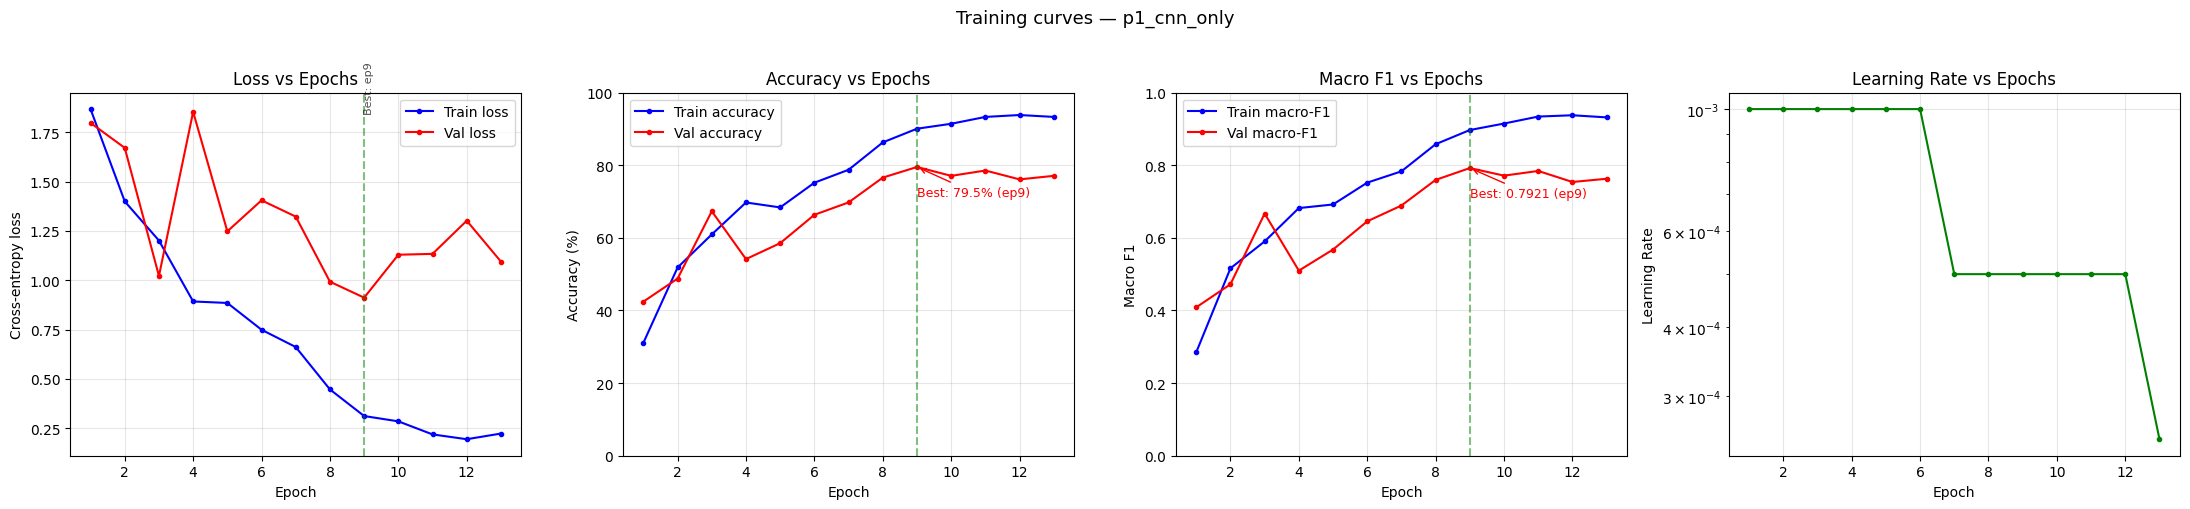

  Best val accuracy : 79.51% (epoch 9)
  Best val macro-F1 : 0.7921 (epoch 9)
  Final learning rate: 2.50e-04

  TEST — p1_cnn_only
  Accuracy  : 79.02%
  Macro F1  : 0.7838
              precision    recall  f1-score   support

       cover     0.7083    0.9444    0.8095        18
     defense     1.0000    1.0000    1.0000        20
       flick     0.7500    0.6000    0.6667        20
        hook     0.6667    0.7000    0.6829        20
    late_cut     0.9474    0.6429    0.7660        28
      lofted     0.4762    0.9091    0.6250        11
        pull     0.7000    0.7000    0.7000        20
  square_cut     0.8261    0.8261    0.8261        23
    straight     1.0000    1.0000    1.0000        22
       sweep     0.8421    0.6957    0.7619        23

    accuracy                         0.7902       205
   macro avg     0.7917    0.8018    0.7838       205
weighted avg     0.8157    0.7902    0.7922       205



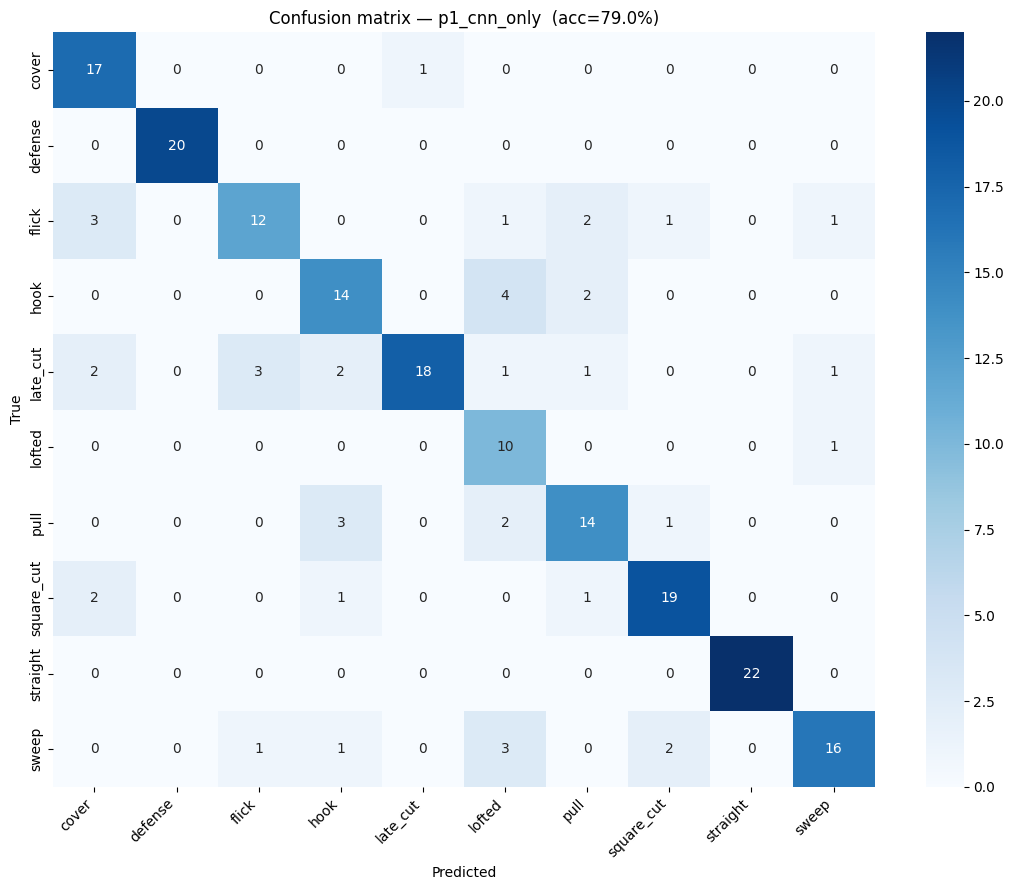


  Per-class confidence (higher = more certain):
    cover       : mean=0.9209, std=0.1399, n=18
    defense     : mean=0.9815, std=0.0376, n=20
    flick       : mean=0.9123, std=0.1182, n=20
    hook        : mean=0.9532, std=0.0949, n=20
    late_cut    : mean=0.8885, std=0.1722, n=28
    lofted      : mean=0.9770, std=0.0621, n=11
    pull        : mean=0.9031, std=0.1136, n=20
    square_cut  : mean=0.8827, std=0.1799, n=23
    straight    : mean=0.9762, std=0.0993, n=22
    sweep       : mean=0.9168, std=0.1563, n=23

  Confidence analysis:
    Correct predictions: mean=0.9580, std=0.0997
    Wrong predictions:   mean=0.8108, std=0.1808

  Most confused pairs (true → predicted):
    hook → lofted: 4 errors
    late_cut → flick: 3 errors
    pull → hook: 3 errors
    sweep → lofted: 3 errors
    flick → cover: 3 errors

Training GRU...

  Training  p1_gru
  LR=0.001  Batch=8  Frames=16
  CNN LR=1e-04 | RNN LR=1e-03
   Ep   tr_loss   tr_acc    tr_f1   vl_loss   vl_acc    vl_f1     

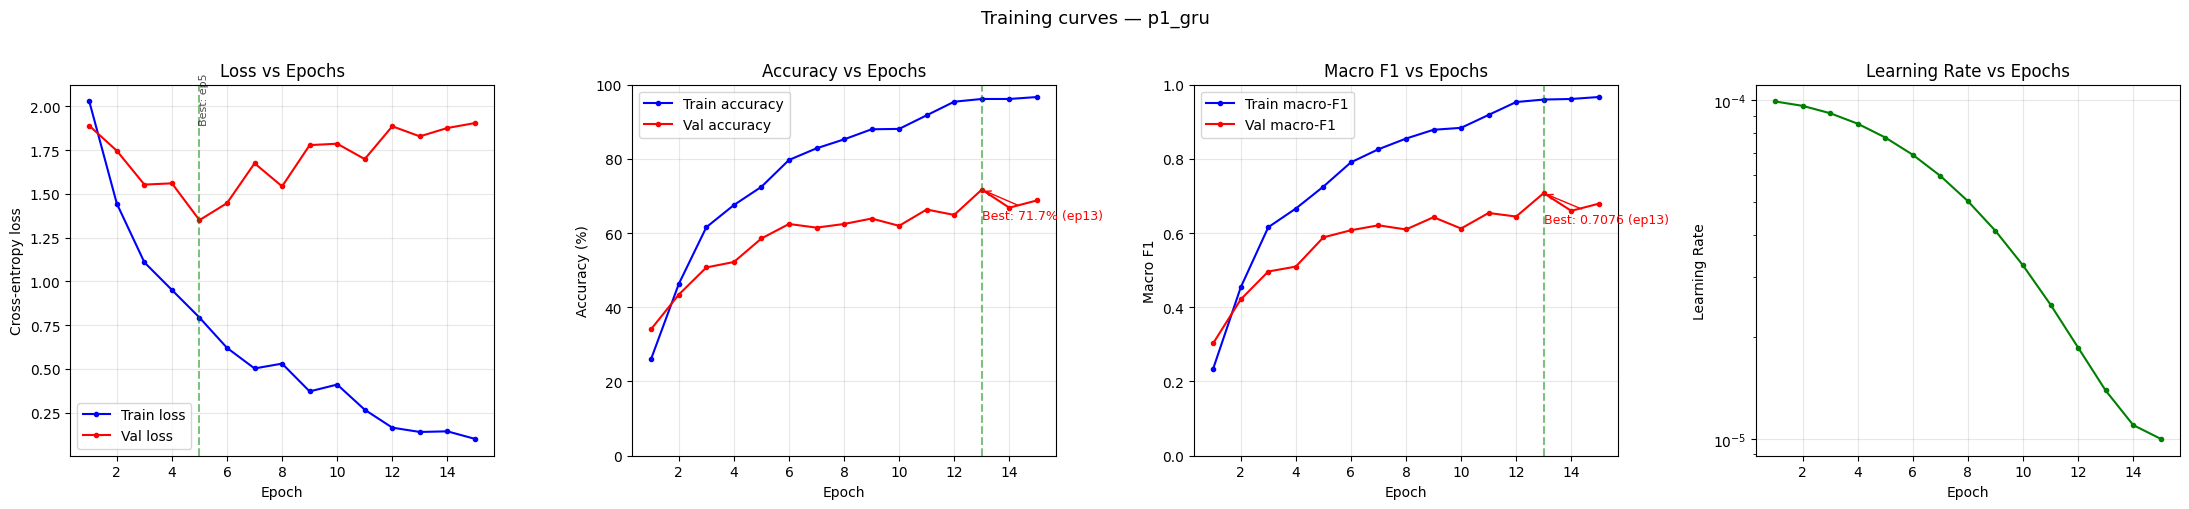

  Best val accuracy : 71.71% (epoch 13)
  Best val macro-F1 : 0.7076 (epoch 13)
  Final learning rate: 1.00e-05

  TEST — p1_gru
  Accuracy  : 74.15%
  Macro F1  : 0.7370
              precision    recall  f1-score   support

       cover     0.4667    0.7778    0.5833        18
     defense     1.0000    0.9500    0.9744        20
       flick     0.7895    0.7500    0.7692        20
        hook     0.8235    0.7000    0.7568        20
    late_cut     0.9545    0.7500    0.8400        28
      lofted     0.4737    0.8182    0.6000        11
        pull     0.4737    0.4500    0.4615        20
  square_cut     0.7647    0.5652    0.6500        23
    straight     1.0000    0.9091    0.9524        22
       sweep     0.7826    0.7826    0.7826        23

    accuracy                         0.7415       205
   macro avg     0.7529    0.7453    0.7370       205
weighted avg     0.7788    0.7415    0.7500       205



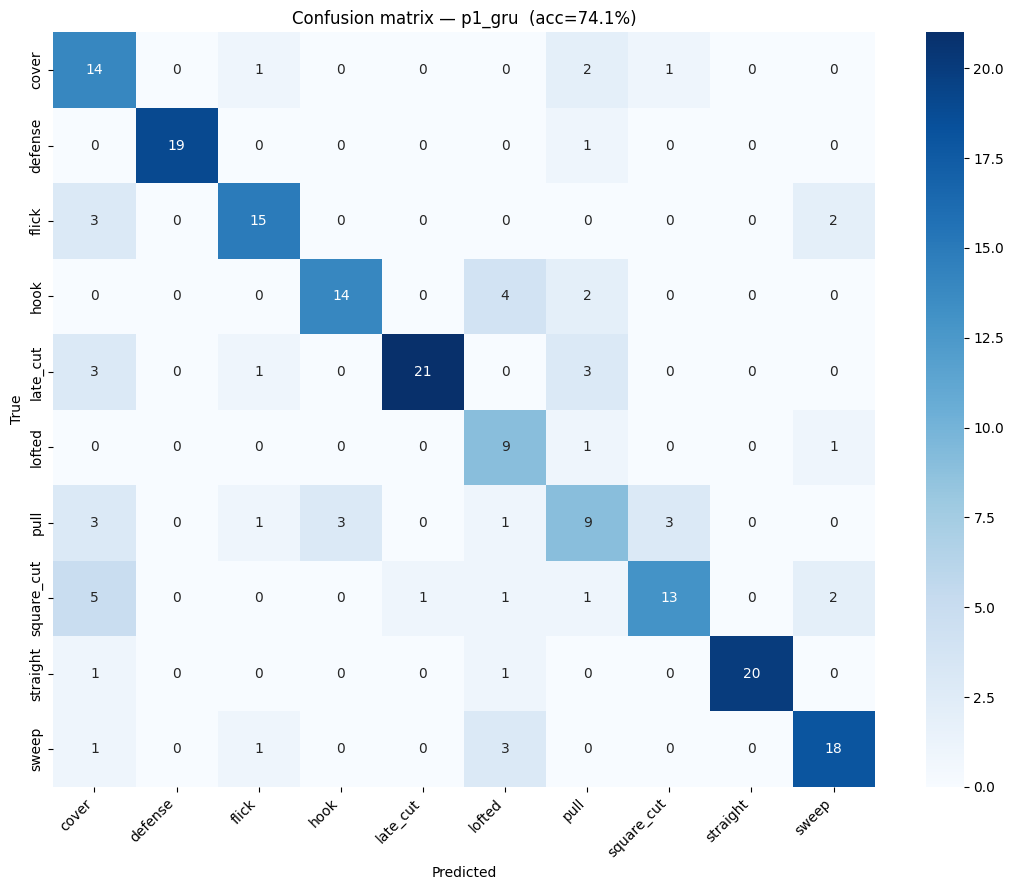


  Per-class confidence (higher = more certain):
    cover       : mean=0.9149, std=0.1354, n=18
    defense     : mean=0.9957, std=0.0145, n=20
    flick       : mean=0.8810, std=0.1963, n=20
    hook        : mean=0.9519, std=0.1270, n=20
    late_cut    : mean=0.9438, std=0.1249, n=28
    lofted      : mean=0.9992, std=0.0024, n=11
    pull        : mean=0.9102, std=0.1565, n=20
    square_cut  : mean=0.9179, std=0.1294, n=23
    straight    : mean=0.9929, std=0.0293, n=22
    sweep       : mean=0.9513, std=0.1018, n=23

  Confidence analysis:
    Correct predictions: mean=0.9681, std=0.0951
    Wrong predictions:   mean=0.8745, std=0.1711

  Most confused pairs (true → predicted):
    square_cut → cover: 5 errors
    hook → lofted: 4 errors
    pull → hook: 3 errors
    flick → cover: 3 errors
    sweep → lofted: 3 errors

Training LSTM...

  Training  p1_lstm
  LR=0.001  Batch=8  Frames=16
  CNN LR=1e-04 | RNN LR=1e-03
   Ep   tr_loss   tr_acc    tr_f1   vl_loss   vl_acc    vl_f1 

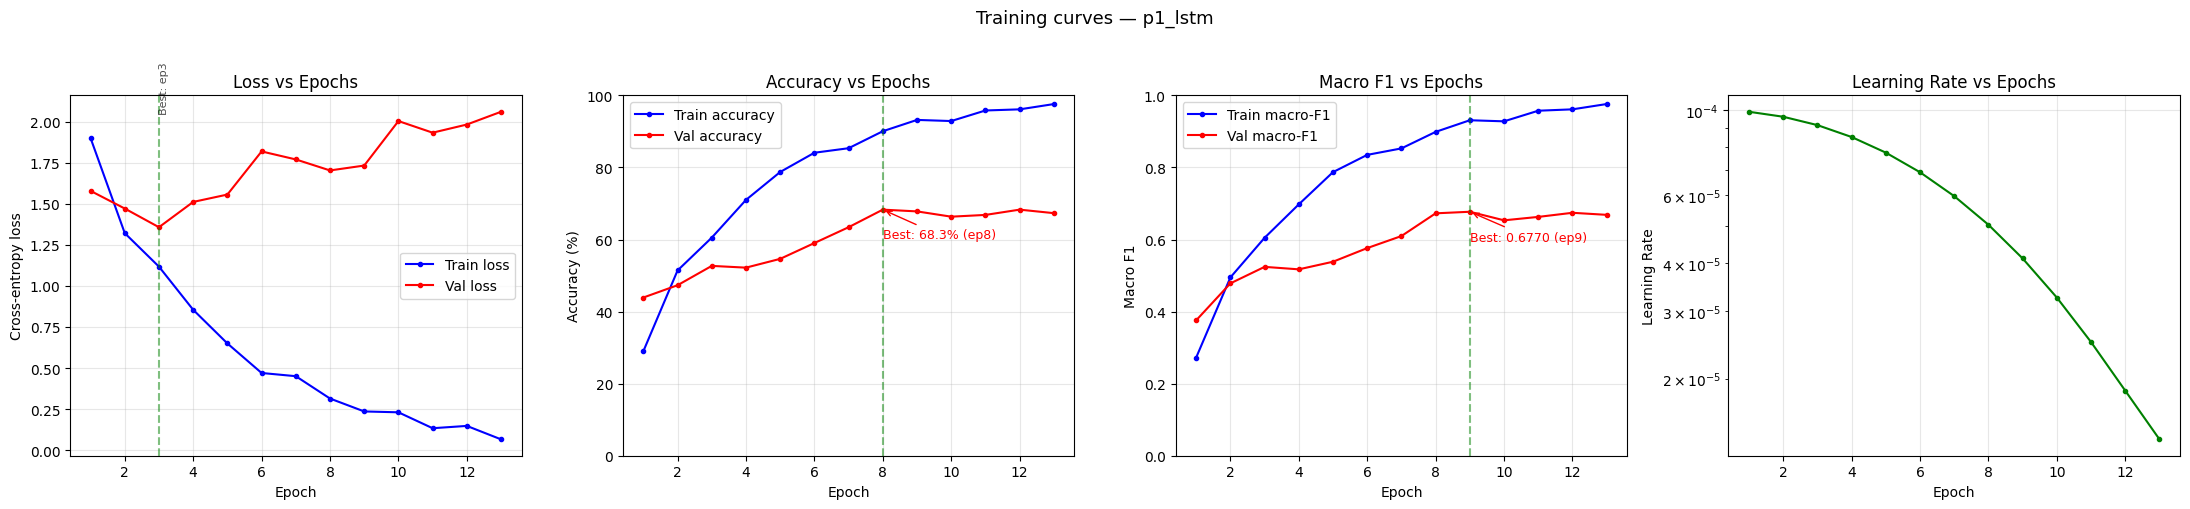

  Best val accuracy : 68.29% (epoch 8)
  Best val macro-F1 : 0.6770 (epoch 9)
  Final learning rate: 1.39e-05

  TEST — p1_lstm
  Accuracy  : 73.66%
  Macro F1  : 0.7250
              precision    recall  f1-score   support

       cover     0.5263    0.5556    0.5405        18
     defense     1.0000    1.0000    1.0000        20
       flick     0.5833    0.7000    0.6364        20
        hook     0.8125    0.6500    0.7222        20
    late_cut     0.8846    0.8214    0.8519        28
      lofted     0.5556    0.9091    0.6897        11
        pull     0.4375    0.3500    0.3889        20
  square_cut     0.6818    0.6522    0.6667        23
    straight     0.9091    0.9091    0.9091        22
       sweep     0.8636    0.8261    0.8444        23

    accuracy                         0.7366       205
   macro avg     0.7254    0.7373    0.7250       205
weighted avg     0.7442    0.7366    0.7360       205



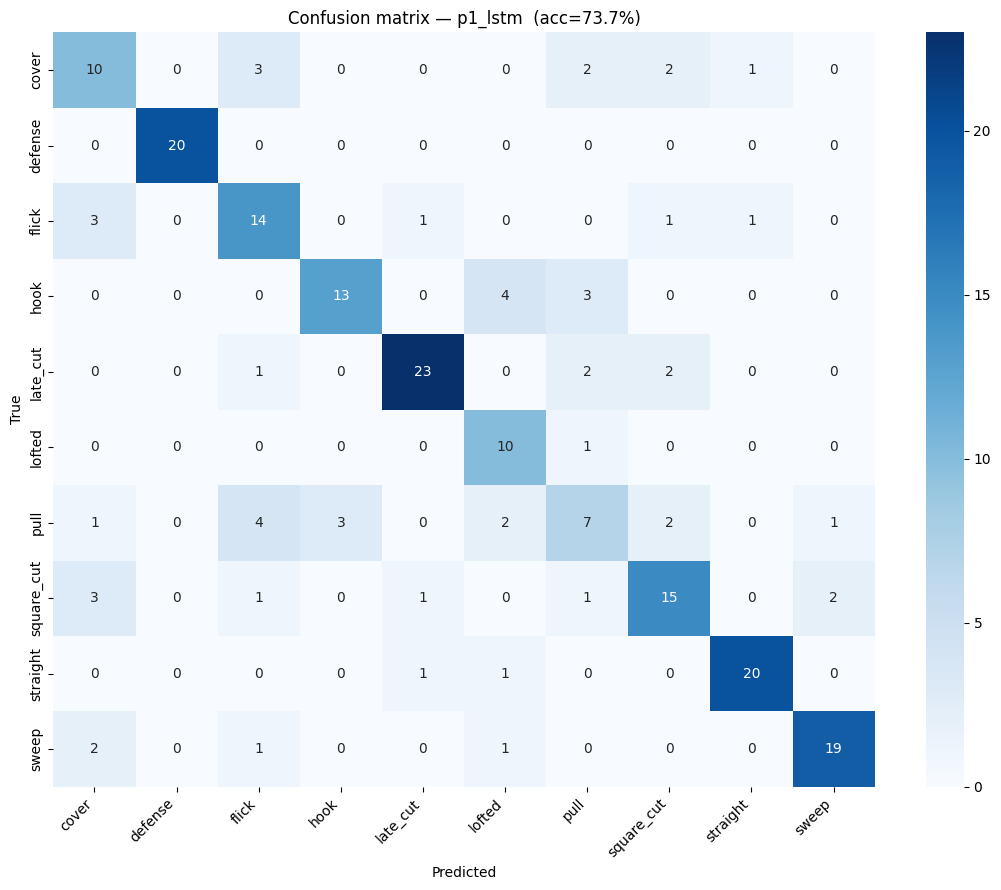


  Per-class confidence (higher = more certain):
    cover       : mean=0.9012, std=0.1435, n=18
    defense     : mean=0.9967, std=0.0077, n=20
    flick       : mean=0.8339, std=0.1799, n=20
    hook        : mean=0.9735, std=0.0747, n=20
    late_cut    : mean=0.9224, std=0.1522, n=28
    lofted      : mean=0.9714, std=0.0614, n=11
    pull        : mean=0.8039, std=0.1996, n=20
    square_cut  : mean=0.8399, std=0.1905, n=23
    straight    : mean=0.9899, std=0.0436, n=22
    sweep       : mean=0.8978, std=0.1734, n=23

  Confidence analysis:
    Correct predictions: mean=0.9398, std=0.1221
    Wrong predictions:   mean=0.8284, std=0.2071

  Most confused pairs (true → predicted):
    hook → lofted: 4 errors
    pull → flick: 4 errors
    hook → pull: 3 errors
    pull → hook: 3 errors
    flick → cover: 3 errors

PHASE 1 SUMMARY
              Val Acc %  Test Acc %  Test Macro-F1  Overfitting Gap %  Epochs
Architecture                                                                

In [ ]:
# phase 1: compare different models using uniform sampling

print("="*60)
print("PHASE 1: Comparing Architectures (Uniform Sampling)")
print("="*60)
print(f"Configuration: {NUM_FRAMES} frames, batch={BATCH_SIZE}, dropout={DROPOUT}, hidden={HIDDEN_SIZE}")
print("="*60)

# get data loaders
tr_u, vl_u, te_u = get_loaders('uniform')
phase1 = {}

# try all models
for arch in ['cnn_only', 'gru', 'lstm']:
    print(f"\n{'='*50}")
    print(f"Training {arch.upper()}...")
    print(f"{'='*50}")
    
    tag = f"p1_{arch}"
    
    # train model
    ckpt, hist, best_vl_acc = train_model(arch, 'uniform', tr_u, vl_u, tag)
    
    # plot training graphs
    plot_curves(hist, tag)
    
    # test model
    test_acc, test_f1, report, class_conf = test_model(arch, tag, te_u)
    
    # store results
    phase1[arch] = {
        'val_acc': best_vl_acc * 100,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'best_epoch': len(hist['tr_loss']),  # how many epochs actually ran
        'final_train_acc': hist['tr_acc'][-1] * 100,
        'final_val_acc': hist['vl_acc'][-1] * 100,
        'overfitting_gap': (hist['tr_acc'][-1] - hist['vl_acc'][-1]) * 100
    }
    
    # save results in text file
    with open(f"{RES_DIR}/phase1_{arch}_report.txt", 'w') as f:
        f.write(f"Architecture: {arch}\n")
        f.write(f"Best val accuracy: {best_vl_acc*100:.2f}%\n")
        f.write(f"Test accuracy: {test_acc:.2f}%\n")
        f.write(f"Test macro F1: {test_f1:.4f}\n")
        f.write(f"Best epoch: {len(hist['tr_loss'])}\n")
        f.write(f"Overfitting gap: {(hist['tr_acc'][-1] - hist['vl_acc'][-1])*100:.2f}%\n")

# convert to dataframe for comparison
df1 = pd.DataFrame(phase1).T
df1 = df1.rename_axis('Architecture')

# reorder columns
df1 = df1[['val_acc', 'test_acc', 'test_f1', 'overfitting_gap', 'best_epoch']]
df1.columns = ['Val Acc %', 'Test Acc %', 'Test Macro-F1', 'Overfitting Gap %', 'Epochs']

# sort by best test accuracy
df1 = df1.sort_values('Test Acc %', ascending=False)

print("\n" + "="*60)
print("PHASE 1 SUMMARY")
print("="*60)
print(df1.to_string(float_format='{:.2f}'.format))

# save csv
df1.to_csv(f"{RES_DIR}/phase1.csv")

# best model
BEST_ARCH = df1.index[0]

print(f"\n{'='*60}")
print(f"Best architecture: {BEST_ARCH.upper()} (Test Acc: {df1.loc[BEST_ARCH, 'Test Acc %']:.2f}%)")
print(f"Overfitting gap: {df1.loc[BEST_ARCH, 'Overfitting Gap %']:.2f}%")
print(f"{'='*60}")

PHASE 2: Sampling Strategy Comparison (GRU Fixed)
Configuration: 16 frames, batch=8, dropout=0.65

✓ Reused Phase 1 GRU + UNIFORM:
    Test acc: 74.15%
    Test F1 : 0.7370

Training GRU with MOTION sampling...
  ✓ Warm-started from Phase 1 GRU checkpoint

  Training  p2_gru_motion
  LR=0.001  Batch=8  Frames=16
  CNN LR=1e-04 | RNN LR=1e-03
   Ep   tr_loss   tr_acc    tr_f1   vl_loss   vl_acc    vl_f1        lr
    1    2.1501   0.1948   0.1811    2.1197   0.2293   0.1927  9.90e-05 ✓
    2    1.8068   0.3414   0.3070    2.0079   0.3268   0.2856  9.61e-05 ✓
    3    1.6518   0.4325   0.4271    1.6530   0.4146   0.3820  9.14e-05 ✓
    4    1.3379   0.5403   0.5243    1.7633   0.4537   0.4342  8.51e-05 ✓
    5    1.1876   0.6000   0.5965    1.8338   0.4244   0.4424  7.75e-05 ✓
    6    1.0140   0.6586   0.6582    1.8809   0.4976   0.4820  6.89e-05 ✓
    7    0.9197   0.7026   0.6925    2.2094   0.4585   0.4342  5.97e-05
    8    0.7609   0.7550   0.7518    1.8603   0.4927   0.4817  5.03e

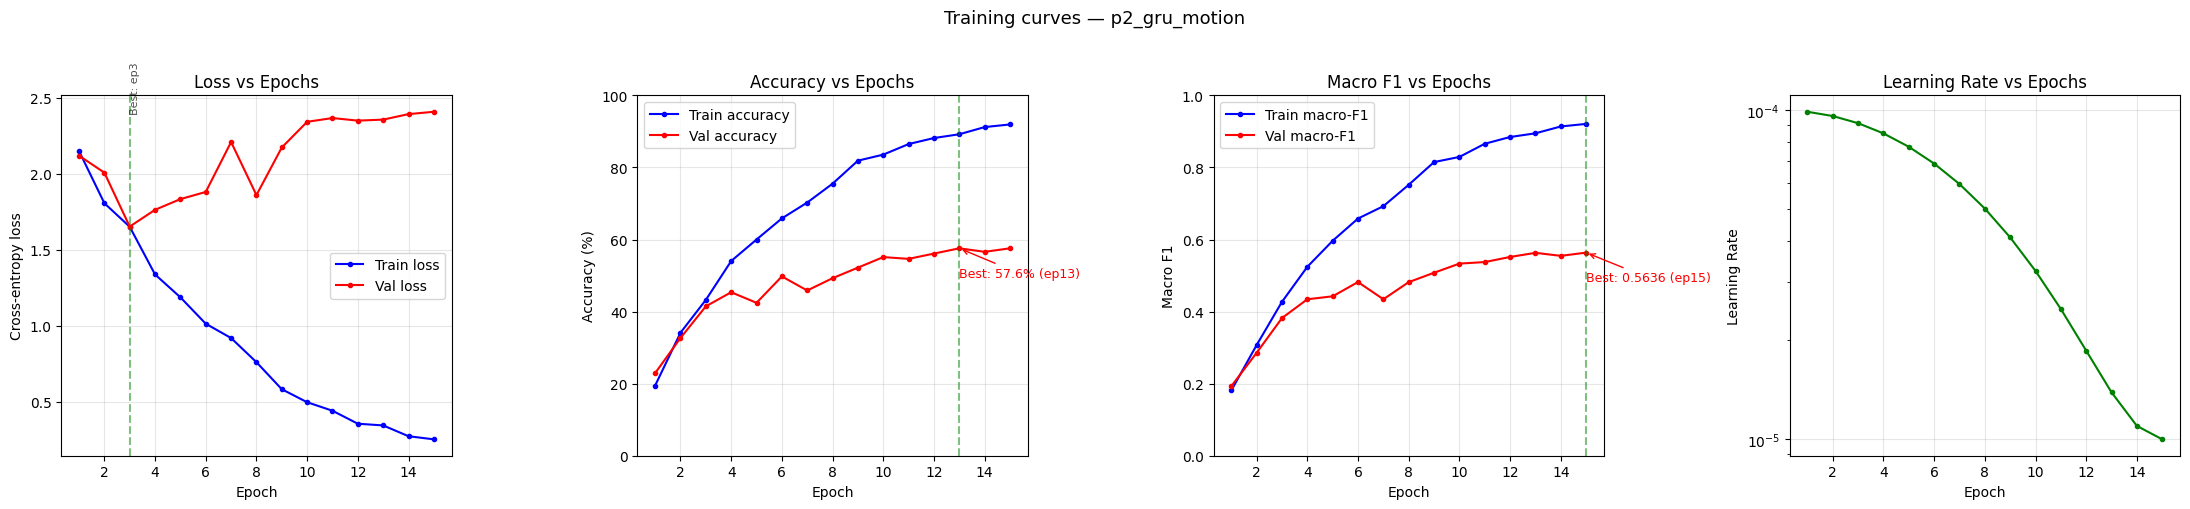

  Best val accuracy : 57.56% (epoch 13)
  Best val macro-F1 : 0.5636 (epoch 15)
  Final learning rate: 1.00e-05

  TEST — p2_gru_motion
  Accuracy  : 57.07%
  Macro F1  : 0.5725
              precision    recall  f1-score   support

       cover     0.5000    0.4444    0.4706        18
     defense     0.9000    0.9000    0.9000        20
       flick     0.3793    0.5500    0.4490        20
        hook     0.6154    0.4000    0.4848        20
    late_cut     0.5517    0.5714    0.5614        28
      lofted     0.5294    0.8182    0.6429        11
        pull     0.4444    0.4000    0.4211        20
  square_cut     0.4783    0.4783    0.4783        23
    straight     0.6500    0.5909    0.6190        22
       sweep     0.7500    0.6522    0.6977        23

    accuracy                         0.5707       205
   macro avg     0.5799    0.5805    0.5725       205
weighted avg     0.5834    0.5707    0.5709       205



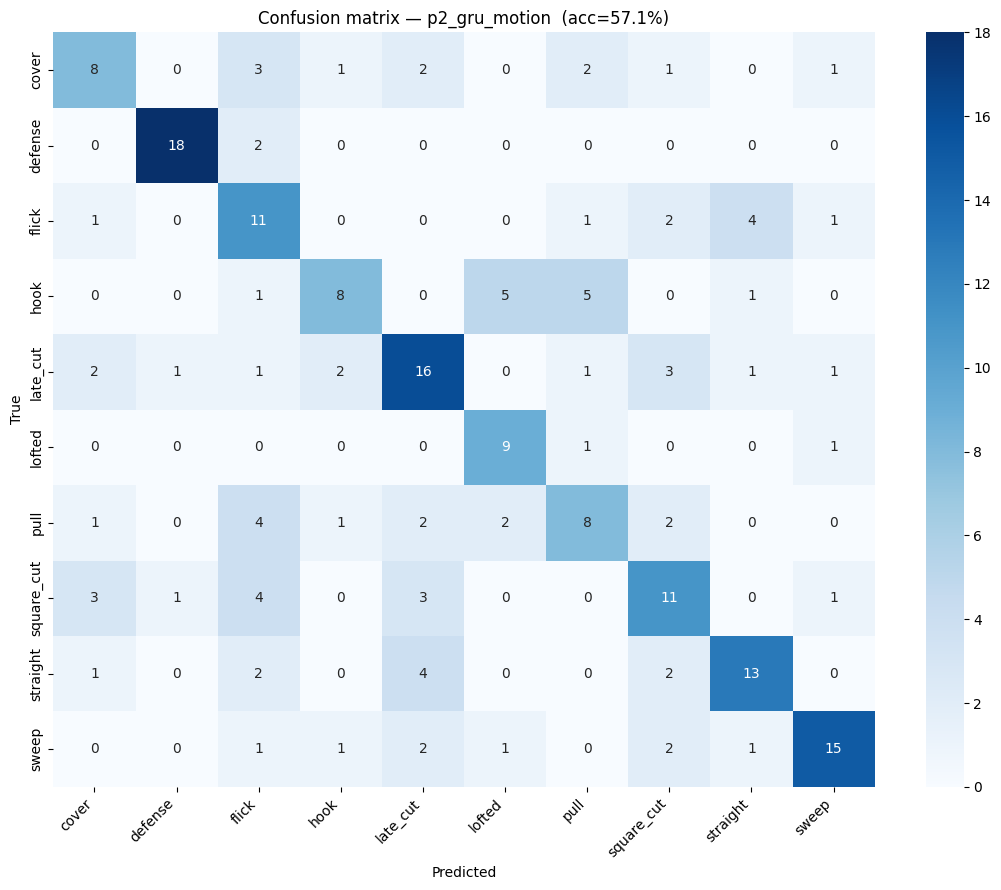


  Per-class confidence (higher = more certain):
    cover       : mean=0.8248, std=0.1812, n=18
    defense     : mean=0.9761, std=0.0953, n=20
    flick       : mean=0.8766, std=0.1918, n=20
    hook        : mean=0.9359, std=0.1141, n=20
    late_cut    : mean=0.8637, std=0.1704, n=28
    lofted      : mean=0.9830, std=0.0343, n=11
    pull        : mean=0.8681, std=0.1441, n=20
    square_cut  : mean=0.8422, std=0.1762, n=23
    straight    : mean=0.9085, std=0.1459, n=22
    sweep       : mean=0.9400, std=0.0947, n=23

  Confidence analysis:
    Correct predictions: mean=0.9398, std=0.1295
    Wrong predictions:   mean=0.8409, std=0.1668

  Most confused pairs (true → predicted):
    hook → pull: 5 errors
    hook → lofted: 5 errors
    straight → late_cut: 4 errors
    pull → flick: 4 errors
    flick → straight: 4 errors

Training GRU with HYBRID sampling...
  ✓ Warm-started from Phase 1 GRU checkpoint

  Training  p2_gru_hybrid
  LR=0.001  Batch=8  Frames=16
  CNN LR=1e-04 | RN

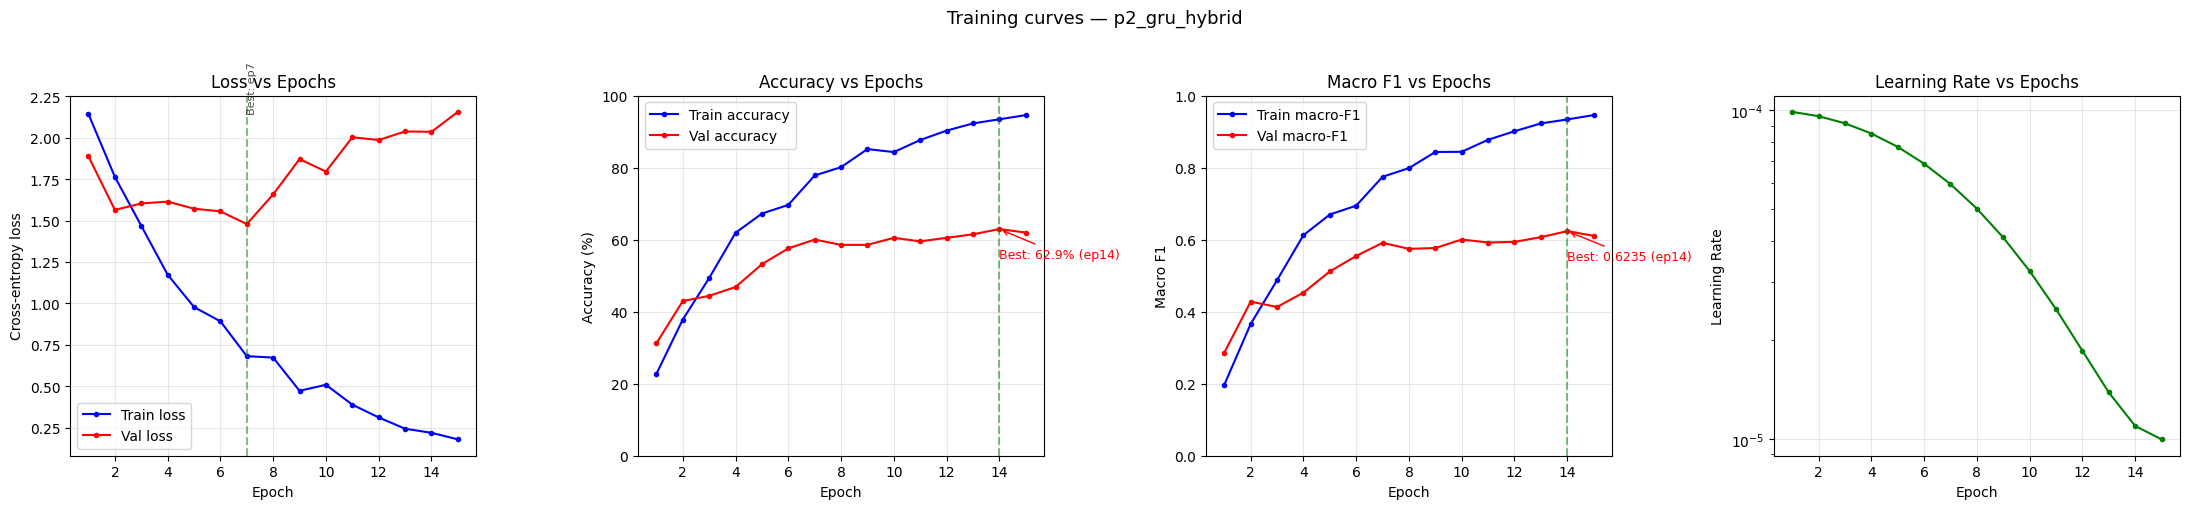

  Best val accuracy : 62.93% (epoch 14)
  Best val macro-F1 : 0.6235 (epoch 14)
  Final learning rate: 1.00e-05

  TEST — p2_gru_hybrid
  Accuracy  : 62.44%
  Macro F1  : 0.6203
              precision    recall  f1-score   support

       cover     0.4762    0.5556    0.5128        18
     defense     0.8636    0.9500    0.9048        20
       flick     0.5172    0.7500    0.6122        20
        hook     0.7143    0.5000    0.5882        20
    late_cut     0.6538    0.6071    0.6296        28
      lofted     0.5625    0.8182    0.6667        11
        pull     0.4375    0.3500    0.3889        20
  square_cut     0.5882    0.4348    0.5000        23
    straight     0.5833    0.6364    0.6087        22
       sweep     0.8500    0.7391    0.7907        23

    accuracy                         0.6244       205
   macro avg     0.6247    0.6341    0.6203       205
weighted avg     0.6324    0.6244    0.6203       205



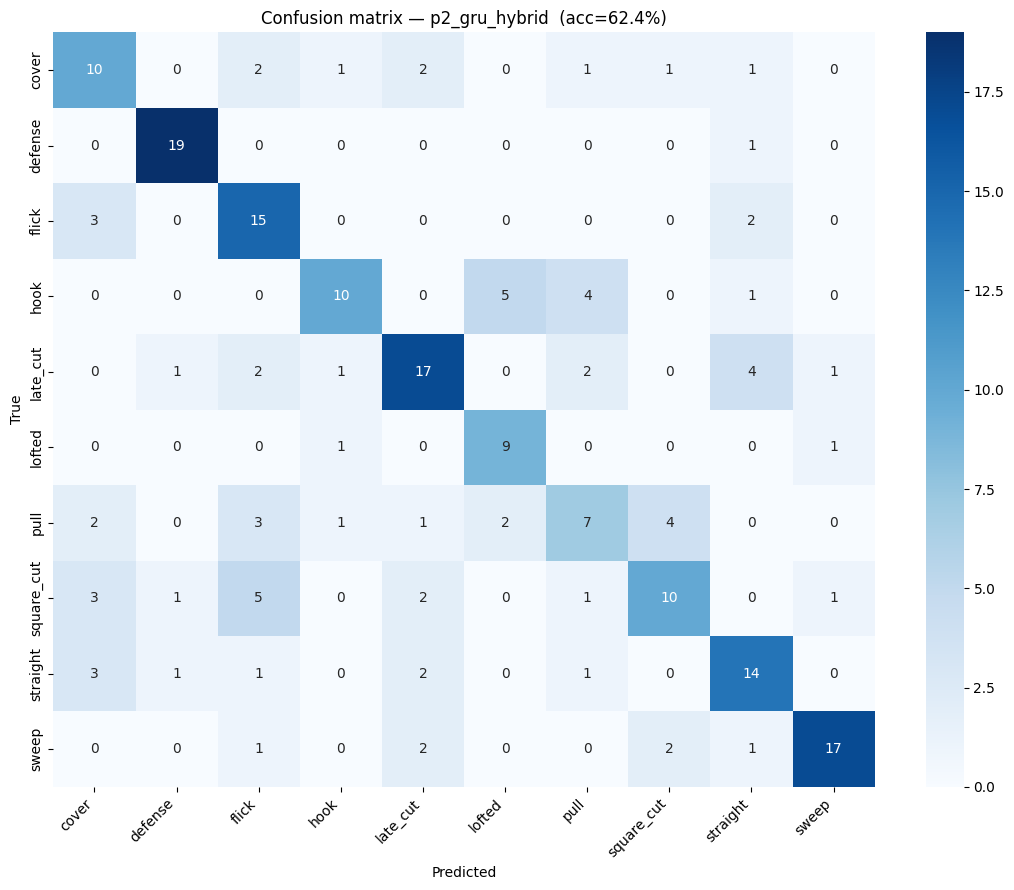


  Per-class confidence (higher = more certain):
    cover       : mean=0.9045, std=0.1260, n=18
    defense     : mean=0.9722, std=0.0963, n=20
    flick       : mean=0.9166, std=0.1550, n=20
    hook        : mean=0.8814, std=0.1634, n=20
    late_cut    : mean=0.8825, std=0.1610, n=28
    lofted      : mean=0.9928, std=0.0189, n=11
    pull        : mean=0.8350, std=0.1772, n=20
    square_cut  : mean=0.8598, std=0.1699, n=23
    straight    : mean=0.9137, std=0.1452, n=22
    sweep       : mean=0.8953, std=0.1760, n=23

  Confidence analysis:
    Correct predictions: mean=0.9440, std=0.1266
    Wrong predictions:   mean=0.8267, std=0.1734

  Most confused pairs (true → predicted):
    hook → lofted: 5 errors
    square_cut → flick: 5 errors
    hook → pull: 4 errors
    late_cut → straight: 4 errors
    pull → square_cut: 4 errors

PHASE 2 SUMMARY (GRU FIXED + FULL ANALYSIS)
         Val Acc % Test Acc % Test Macro-F1 Overfitting Gap % Epochs
Sampling                               

In [ ]:
# phase 2: compare sampling methods using GRU

import shutil
phase2 = {}

BEST_ARCH = 'gru'  # fixing GRU model

print("="*60)
print("PHASE 2: Sampling Strategy Comparison (GRU Fixed)")
print("="*60)
print(f"Configuration: {NUM_FRAMES} frames, batch={BATCH_SIZE}, dropout={DROPOUT}")
print("="*60)

# reuse GRU + uniform result from phase 1
phase2['uniform'] = phase1['gru'].copy()
phase2['uniform']['reused'] = True
phase2['uniform']['sampling'] = 'uniform'

print(f"\nReused Phase 1 GRU + UNIFORM:")
print(f"  Test acc: {phase1['gru']['test_acc']:.2f}%")
print(f"  Test F1 : {phase1['gru']['test_f1']:.4f}")

# train for motion and hybrid
for strategy in ['motion', 'hybrid']:
    print(f"\n{'='*50}")
    print(f"Training GRU with {strategy.upper()} sampling...")
    print(f"{'='*50}")
    
    tr_s, vl_s, te_s = get_loaders(strategy)
    tag = f"p2_gru_{strategy}"
    p1_ckpt = f"{CKPT_DIR}/p1_gru.pth"

    # copy old weights if available
    if os.path.exists(p1_ckpt):
        shutil.copy(p1_ckpt, f"{CKPT_DIR}/{tag}.pth")
        print("  warm start from phase 1")

    # train model
    ckpt, hist, best_vl_acc = train_model('gru', strategy, tr_s, vl_s, tag)
    
    # plot graphs
    plot_curves(hist, tag)

    # test model
    test_acc, test_f1, report, class_conf = test_model('gru', tag, te_s)

    # store results
    phase2[strategy] = {
        'val_acc': best_vl_acc * 100,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'sampling': strategy,
        'reused': False,
        'best_epoch': len(hist['tr_loss']),
        'final_train_acc': hist['tr_acc'][-1] * 100,
        'final_val_acc': hist['vl_acc'][-1] * 100,
        'overfitting_gap': (hist['tr_acc'][-1] - hist['vl_acc'][-1]) * 100
    }

    # save results
    with open(f"{RES_DIR}/phase2_gru_{strategy}_report.txt", 'w') as f:
        f.write(f"Architecture: GRU\n")
        f.write(f"Sampling strategy: {strategy}\n")
        f.write(f"Best val accuracy: {best_vl_acc*100:.2f}%\n")
        f.write(f"Test accuracy: {test_acc:.2f}%\n")
        f.write(f"Test macro F1: {test_f1:.4f}\n")
        f.write(f"Best epoch: {len(hist['tr_loss'])}\n")
        f.write(f"Overfitting gap: {(hist['tr_acc'][-1] - hist['vl_acc'][-1])*100:.2f}%\n")

# create dataframe
df2 = pd.DataFrame(phase2).T
df2 = df2.rename_axis('Sampling')

df2 = df2[['val_acc', 'test_acc', 'test_f1', 'overfitting_gap', 'best_epoch']]
df2.columns = ['Val Acc %', 'Test Acc %', 'Test Macro-F1', 'Overfitting Gap %', 'Epochs']

# sort results
df2 = df2.sort_values('Test Acc %', ascending=False)

print("\n" + "="*60)
print("PHASE 2 SUMMARY")
print("="*60)
print(df2.to_string(float_format='{:.2f}'.format))

# save csv
df2.to_csv(f"{RES_DIR}/phase2_corrected.csv")

# best strategy
BEST_STRATEGY = df2.index[0]
best_test_acc = df2.loc[BEST_STRATEGY, 'Test Acc %']
best_test_f1 = df2.loc[BEST_STRATEGY, 'Test Macro-F1']

print(f"\n{'='*60}")
print(f"Best sampling strategy: {BEST_STRATEGY.upper()}")
print(f"Test Accuracy: {best_test_acc:.2f}%")
print(f"Test Macro F1: {best_test_f1:.4f}")
print(f"Overfitting gap: {df2.loc[BEST_STRATEGY, 'Overfitting Gap %']:.2f}%")
print(f"{'='*60}")

# compare with uniform
uniform_acc = phase1['gru']['test_acc']
improvement = best_test_acc - uniform_acc

print(f"\nImprovement over uniform sampling: +{improvement:.2f}%")

PHASE 3: Comparing Aggregation Methods
Architecture: GRU
Sampling strategy: uniform
Model checkpoint: /kaggle/working/checkpoints/p1_gru.pth

Sampling test videos...
  cover: 5/18 videos
  defense: 5/20 videos
  flick: 5/20 videos
  hook: 5/20 videos
  late_cut: 5/28 videos
  lofted: 5/11 videos
  pull: 5/20 videos
  square_cut: 5/23 videos
  straight: 5/22 videos
  sweep: 5/23 videos

Running Phase 3 on 50 videos...
Processing: cover_0170.avi (46 frames)
Processing: cover_0095.avi (55 frames)
Processing: cover_0149.avi (71 frames)
Processing: cover_0074.avi (88 frames)
Processing: cover_0157.avi (59 frames)
Processing: defense_0016.avi (88 frames)
Processing: defense_0065.avi (90 frames)
Processing: defense_0045.avi (98 frames)
Processing: defense_0182.avi (93 frames)
Processing: defense_0138.avi (65 frames)
Processing: flick_0122.avi (35 frames)
Processing: flick_0144.avi (47 frames)
Processing: flick_0139.avi (51 frames)
Processing: flick_0172.avi (46 frames)
Processing: flick_0036.

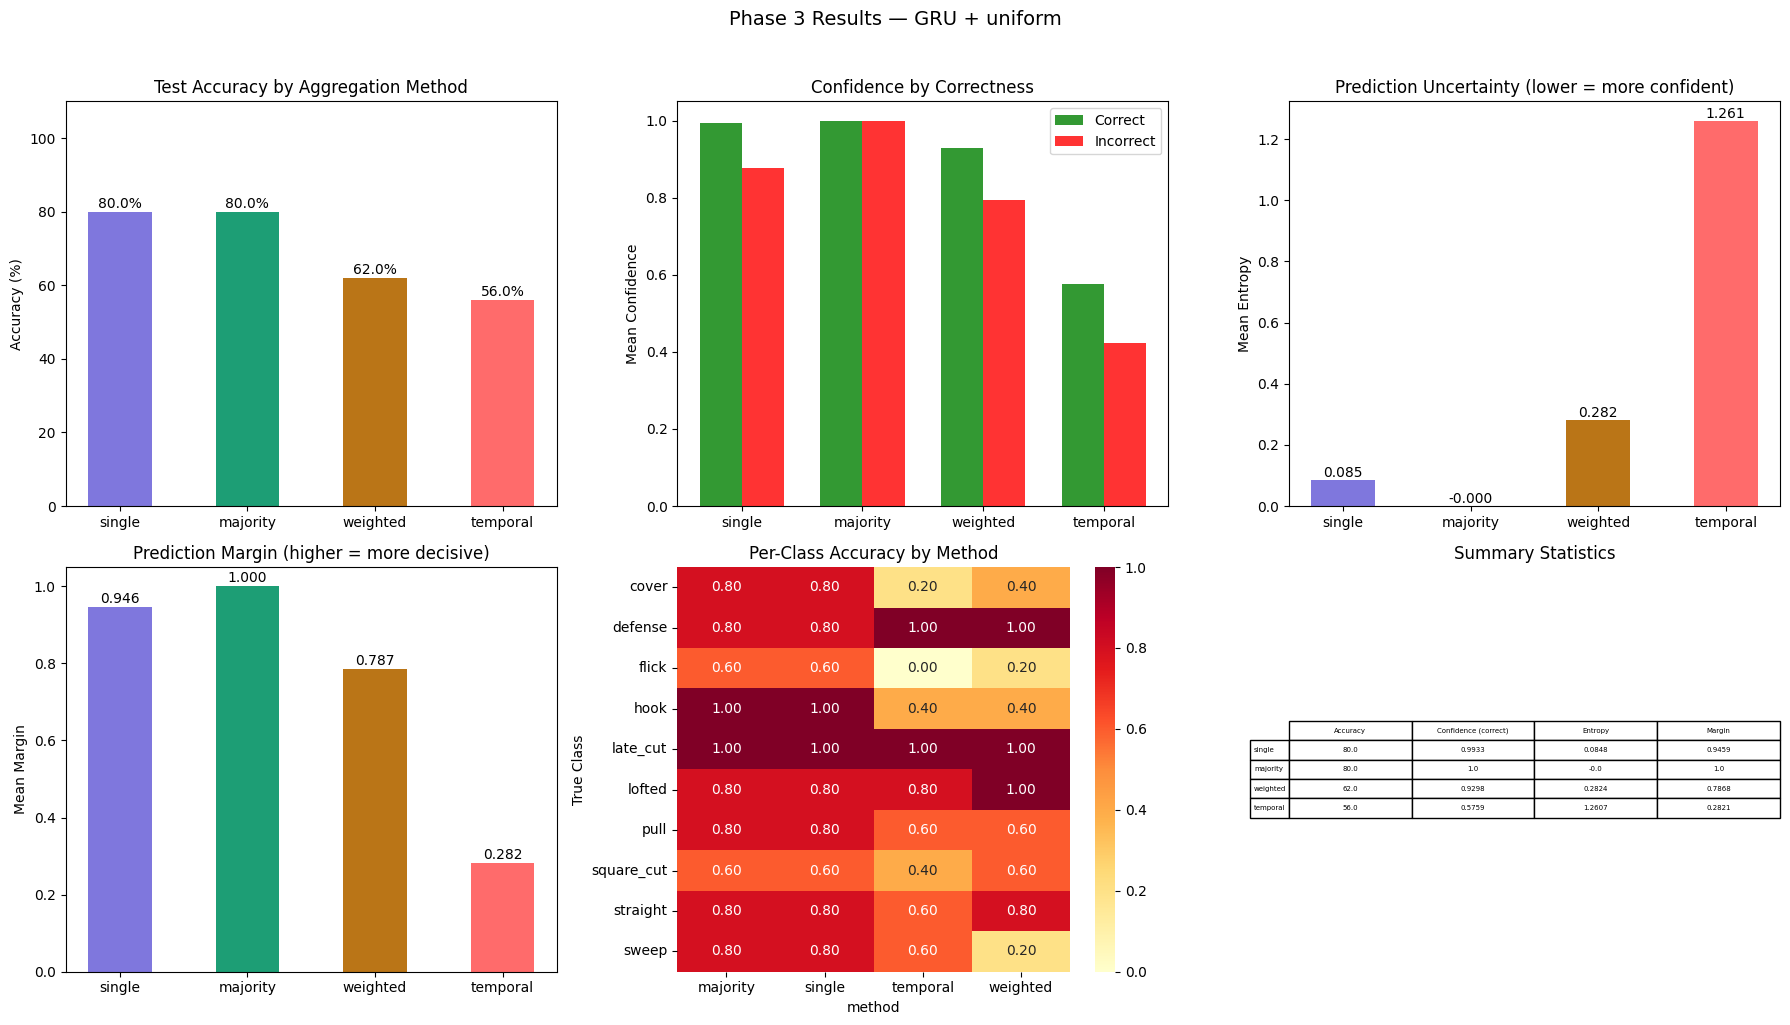


PHASE 3 SUMMARY
          Accuracy  Confidence (correct)       Entropy    Margin
Method                                                          
single        80.0              0.993305  8.484099e-02  0.945943
majority      80.0              1.000000 -1.000000e-09  1.000000
weighted      62.0              0.929781  2.823943e-01  0.786778
temporal      56.0              0.575922  1.260703e+00  0.282096


✓ Best aggregation method: SINGLE (Accuracy: 80.00%)


In [ ]:
# phase 3: compare aggregation methods (no extra training)

# use GRU model
BEST_ARCH = 'gru'

_p3_model = get_model('gru')

# choose checkpoint based on best sampling
_p3_ckpt = (f"{CKPT_DIR}/p2_gru_{BEST_STRATEGY}.pth"
            if BEST_STRATEGY != 'uniform'
            else f"{CKPT_DIR}/p1_gru.pth")

# load model
_p3_model.load_state_dict(torch.load(_p3_ckpt, map_location=DEVICE))
_p3_model.eval()

print("="*60)
print("PHASE 3: Comparing Aggregation Methods")
print("="*60)
print(f"Architecture: {BEST_ARCH.upper()}")
print(f"Sampling strategy: {BEST_STRATEGY}")
print(f"Model checkpoint: {_p3_ckpt}")
print("="*60)

# basic transform
_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def _to_tensor(frames):
    # convert frames to tensor
    return torch.stack([_tf(f) for f in frames]).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def predict_single(frames):
    # simple single prediction
    s = sample_frames(frames, NUM_FRAMES, BEST_STRATEGY)
    return torch.softmax(_p3_model(_to_tensor(s)), 1).squeeze().cpu().numpy()

@torch.no_grad()
def predict_majority_voting(frames, n=5):
    # run multiple predictions and take majority
    votes = np.zeros(NUM_CLASSES)
    for _ in range(n):
        s = sample_frames(frames, NUM_FRAMES, BEST_STRATEGY)
        
        # small shift in frames
        if len(s) > NUM_FRAMES + 2:
            shift = random.randint(-2, 2)
            if shift > 0:
                s = s[shift:] + [s[-1]] * shift
            elif shift < 0:
                s = [s[0]] * abs(shift) + s[:shift]
        
        pred = _p3_model(_to_tensor(s[:NUM_FRAMES])).argmax(1).item()
        votes[pred] += 1
    
    return votes / votes.sum()

@torch.no_grad()
def predict_weighted_voting(frames, n=5):
    # weighted voting using motion
    scores = compute_motion_scores(frames)
    agg, wt = np.zeros(NUM_CLASSES), 0.0
    
    for _ in range(n):
        top_n = min(len(frames), int(NUM_FRAMES * 1.5))
        chosen = np.sort(np.random.choice(
            np.argsort(scores)[-top_n:],
            size=min(NUM_FRAMES, top_n), replace=False))
        
        # weight using motion score
        w = float(scores[chosen].mean() + 1e-6)
        
        s = [frames[i] for i in chosen]
        
        # pad if needed
        while len(s) < NUM_FRAMES:
            s.append(s[-1])
        
        p = torch.softmax(_p3_model(_to_tensor(s[:NUM_FRAMES])), 1)
        agg += w * p.squeeze().cpu().numpy()
        wt += w
    
    return agg / wt

@torch.no_grad()
def predict_temporal_consistency(frames, window_size=5):
    # sliding window approach
    if len(frames) < window_size:
        return predict_single(frames)
    
    all_probs = []
    for start in range(0, len(frames) - window_size + 1, window_size // 2):
        window = frames[start:start + window_size]
        s = sample_frames(window, NUM_FRAMES, BEST_STRATEGY)
        probs = torch.softmax(_p3_model(_to_tensor(s)), 1).squeeze().cpu().numpy()
        all_probs.append(probs)
    
    # average all predictions
    return np.mean(all_probs, axis=0)

def run_phase3(video_paths, true_labels):
    # run all methods on given videos
    rows = []
    
    methods = [
        ('single', predict_single),
        ('majority', predict_majority_voting),
        ('weighted', predict_weighted_voting),
        ('temporal', predict_temporal_consistency)
    ]
    
    for path, lbl in zip(video_paths, true_labels):
        print(f"Processing: {os.path.basename(path)}", end=" ")
        
        frames = extract_frames(path)
        if not frames:
            print(" skip")
            continue
        
        print(f"({len(frames)} frames)")
        
        for method_name, predict_fn in methods:
            try:
                probs = predict_fn(frames)
                pred = int(np.argmax(probs))
                
                rows.append({
                    'video': os.path.basename(path),
                    'true_class': CLASSES[lbl],
                    'method': method_name,
                    'predicted': CLASSES[pred],
                    'correct': CLASSES[pred] == CLASSES[lbl],
                    'confidence': float(probs[pred]),
                    'entropy': float(-np.sum(probs * np.log(probs + 1e-9))),
                    'top1_prob': float(probs[pred]),
                    'top2_prob': float(np.sort(probs)[-2]) if len(probs) > 1 else 0,
                    'margin': float(probs[pred] - (np.sort(probs)[-2] if len(probs) > 1 else 0))
                })
            except Exception as e:
                print(f" error in {method_name}")
                
                rows.append({
                    'video': os.path.basename(path),
                    'true_class': CLASSES[lbl],
                    'method': method_name,
                    'predicted': 'ERROR',
                    'correct': False,
                    'confidence': 0.0,
                    'entropy': 0.0,
                    'top1_prob': 0.0,
                    'top2_prob': 0.0,
                    'margin': 0.0
                })
    
    return pd.DataFrame(rows)


# pick some test samples
print("\nSampling test videos...")
s = _shared_splits
paths3, labels3 = [], []
samples_per_class = 5

for ci in range(NUM_CLASSES):
    idxs = [i for i, l in enumerate(s['y_te']) if l == ci]
    n_samples = min(samples_per_class, len(idxs))
    
    sampled_idxs = random.sample(idxs, n_samples)
    for i in sampled_idxs:
        paths3.append(s['X_te'][i])
        labels3.append(ci)
    
    print(f"  {CLASSES[ci]}: {n_samples}/{len(idxs)} videos")

print(f"\nRunning Phase 3 on {len(paths3)} videos...")
df3 = run_phase3(paths3, labels3)

# save results
df3.to_csv(f"{RES_DIR}/phase3.csv", index=False)

# plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
methods = ['single', 'majority', 'weighted', 'temporal']
colors = ['#7F77DD', '#1D9E75', '#BA7517', '#FF6B6B']

# accuracy
acc = df3.groupby('method')['correct'].mean().reindex(methods) * 100
axes[0, 0].bar(methods, acc, color=colors[:len(methods)], width=0.5)
axes[0, 0].set_ylim(0, 110)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Accuracy by Method')

# confidence
conf_ok = df3[df3['correct']].groupby('method')['confidence'].mean().reindex(methods)
conf_no = df3[~df3['correct']].groupby('method')['confidence'].mean().reindex(methods)
x = np.arange(len(methods))
width = 0.35

axes[0, 1].bar(x - width/2, conf_ok, width, label='Correct')
axes[0, 1].bar(x + width/2, conf_no, width, label='Wrong')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(methods)
axes[0, 1].set_title('Confidence')

# entropy
ent = df3.groupby('method')['entropy'].mean().reindex(methods)
axes[0, 2].bar(methods, ent, color=colors[:len(methods)], width=0.5)
axes[0, 2].set_title('Entropy')

# margin
margin = df3.groupby('method')['margin'].mean().reindex(methods)
axes[1, 0].bar(methods, margin, color=colors[:len(methods)], width=0.5)
axes[1, 0].set_title('Margin')

# per class heatmap
pivot = df3.pivot_table(index='true_class', columns='method', values='correct', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Per Class Accuracy')

# summary table
summary_data = []
for method in methods:
    method_df = df3[df3['method'] == method]
    summary_data.append({
        'Method': method,
        'Accuracy': method_df['correct'].mean() * 100,
        'Confidence': method_df['confidence'].mean(),
        'Entropy': method_df['entropy'].mean(),
        'Margin': method_df['margin'].mean()
    })

summary_df = pd.DataFrame(summary_data).set_index('Method')

axes[1, 2].axis('off')
axes[1, 2].table(cellText=summary_df.round(4).values,
                 colLabels=summary_df.columns,
                 rowLabels=summary_df.index,
                 cellLoc='center',
                 loc='center')

plt.tight_layout()
plt.savefig(f"{RES_DIR}/phase3.png", dpi=150)
plt.show()

# final results
print("\n" + "="*60)
print("PHASE 3 SUMMARY")
print("="*60)
print(summary_df.to_string())

best_method = summary_df['Accuracy'].idxmax()
best_acc = summary_df.loc[best_method, 'Accuracy']

print(f"\nBest aggregation method: {best_method.upper()} (Accuracy: {best_acc:.2f}%)")